# VAE Portfolio Project - Data Exploration

This notebook loads historical market data for multiple stock indices and explores their characteristics.

In [1]:
# Import libraries
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import PortfolioDataLoader
from utils import PortfolioConfig

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Configuration and Data

In [2]:
# Load configuration
config = PortfolioConfig()

print(f"Portfolio Indices: {config.indices}")
print(f"Start Date: {config.start_date}")
print(f"End Date: {config.end_date}")
print(f"Weights: {config.weights}")

Portfolio Indices: ['^GSPC', '^STOXX50E', '^N225', '^HSI']
Start Date: 2015-01-01
End Date: 2023-12-31
Weights: [0.4 0.3 0.2 0.1]


In [3]:
# Fetch data from Yahoo Finance
loader = PortfolioDataLoader(config.indices, config.start_date, config.end_date)
prices = loader.fetch_data()

print("\nFirst few rows:")
print(prices.head())
print(f"\nShape: {prices.shape}")

Fetching data for 4 indices...
✓ Successfully loaded data. Shape: (2002, 4)

First few rows:
Ticker            ^GSPC          ^HSI         ^N225    ^STOXX50E
Date                                                            
2015-01-05  2020.579956  23721.320312  17408.710938  3023.139893
2015-01-07  2025.900024  23681.259766  16885.330078  3026.790039
2015-01-08  2062.139893  23835.529297  17167.099609  3135.080078
2015-01-09  2044.810059  23919.949219  17197.730469  3042.899902
2015-01-13  2023.030029  24215.970703  17087.710938  3133.860107

Shape: (2002, 4)


## 2. Calculate Returns

In [4]:
# Calculate log returns
returns = loader.calculate_returns(method='log')

print("First few returns:")
print(returns.head())
print(f"\nReturns statistics:")
print(returns.describe())

Returns shape: (2001, 4)
Mean returns:
Ticker
^GSPC        0.000429
^HSI        -0.000165
^N225        0.000327
^STOXX50E    0.000201
dtype: float64

First few returns:
Ticker         ^GSPC      ^HSI     ^N225  ^STOXX50E
Date                                               
2015-01-07  0.002629 -0.001690 -0.030526   0.001207
2015-01-08  0.017730  0.006493  0.016550   0.035152
2015-01-09 -0.008439  0.003536  0.001783  -0.029844
2015-01-13 -0.010709  0.012300 -0.006418   0.029455
2015-01-14 -0.005830 -0.004278 -0.017221  -0.014201

Returns statistics:
Ticker        ^GSPC         ^HSI        ^N225    ^STOXX50E
count   2001.000000  2001.000000  2001.000000  2001.000000
mean       0.000429    -0.000165     0.000327     0.000201
std        0.012126     0.013915     0.013263     0.013163
min       -0.127652    -0.065673    -0.117658    -0.132405
25%       -0.004079    -0.007417    -0.006008    -0.005368
50%        0.000634     0.000228     0.000692     0.000777
75%        0.006106     0.007192 

## 3. Data Summary Statistics

In [5]:
# Get summary
summary = loader.get_data_summary()
summary_df = pd.DataFrame(summary)
print("\nSummary Statistics:")
print(summary_df)


Summary Statistics:
               mean       std       min       max    sharpe
Ticker                                                     
^GSPC      0.000429  0.012126 -0.127652  0.089683  0.561922
^HSI      -0.000165  0.013915 -0.065673  0.086928 -0.188355
^N225      0.000327  0.013263 -0.117658  0.077314  0.390882
^STOXX50E  0.000201  0.013163 -0.132405  0.088343  0.242629


## 4. Visualization - Returns Distribution

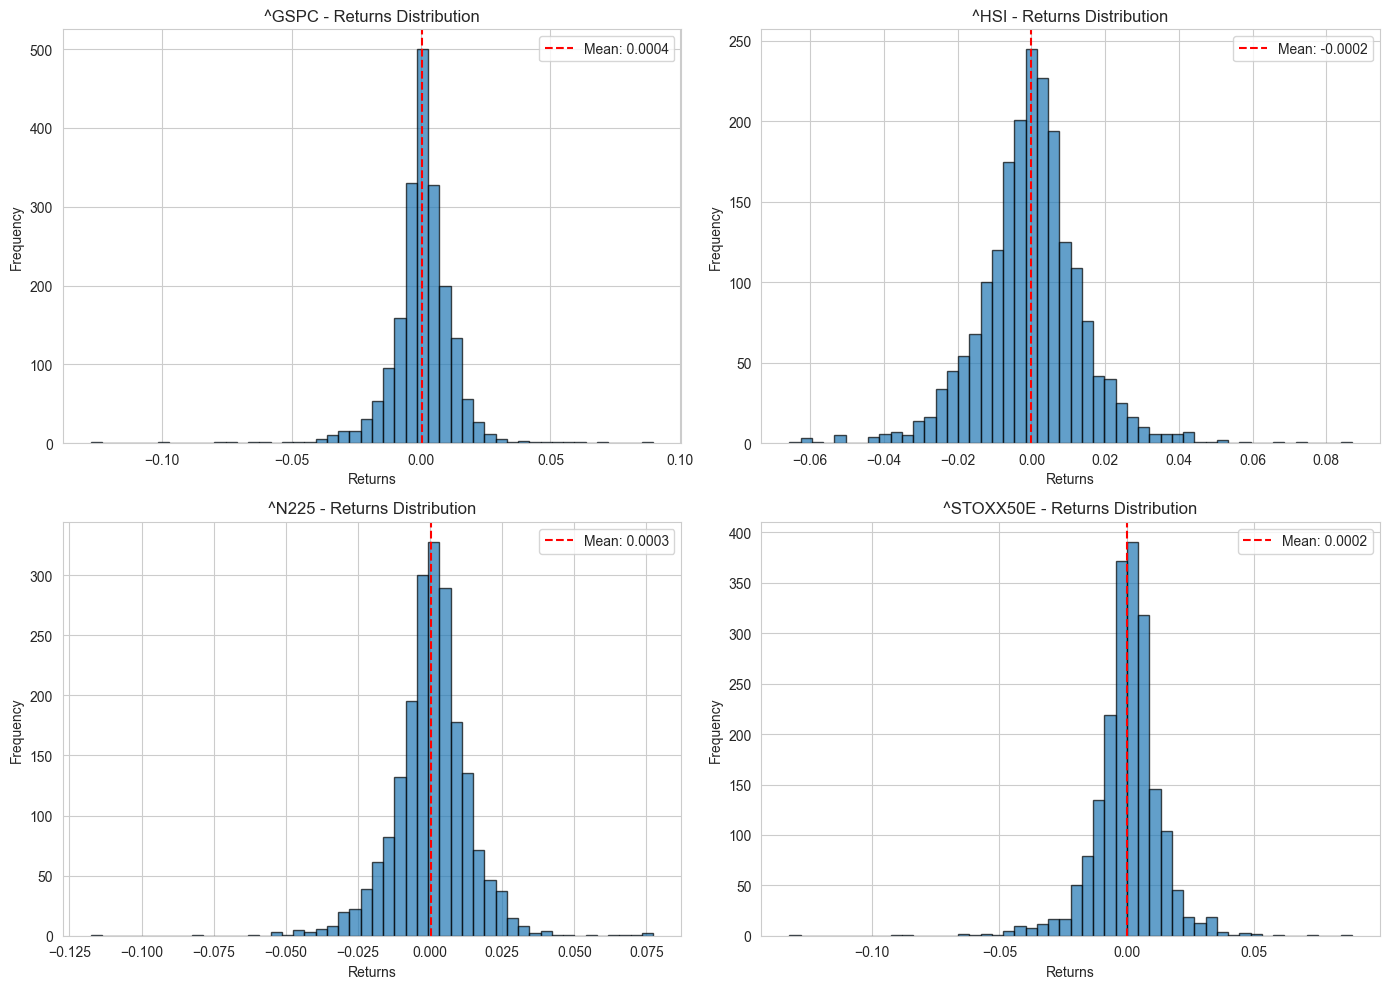

In [6]:
# Plot returns distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(returns.columns):
    axes[idx].hist(returns[col], bins=50, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{col} - Returns Distribution')
    axes[idx].set_xlabel('Returns')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(returns[col].mean(), color='red', linestyle='--', label=f'Mean: {returns[col].mean():.4f}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../results/01_returns_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Correlation Matrix

Correlation Matrix:
Ticker        ^GSPC      ^HSI     ^N225  ^STOXX50E
Ticker                                            
^GSPC      1.000000  0.248703  0.236938   0.602240
^HSI       0.248703  1.000000  0.524508   0.407521
^N225      0.236938  0.524508  1.000000   0.406305
^STOXX50E  0.602240  0.407521  0.406305   1.000000


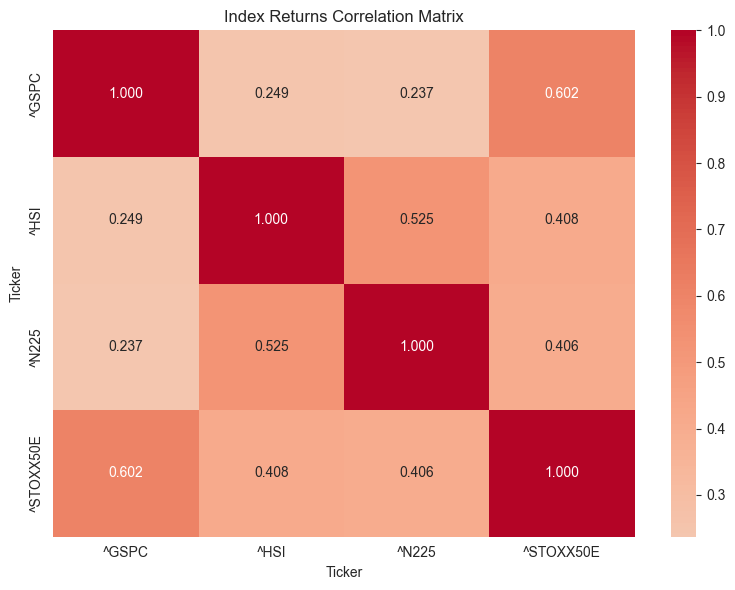

In [7]:
# Calculate correlation matrix
corr_matrix = returns.corr()

print("Correlation Matrix:")
print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Index Returns Correlation Matrix')
plt.tight_layout()
plt.savefig('../results/02_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Time Series Plot

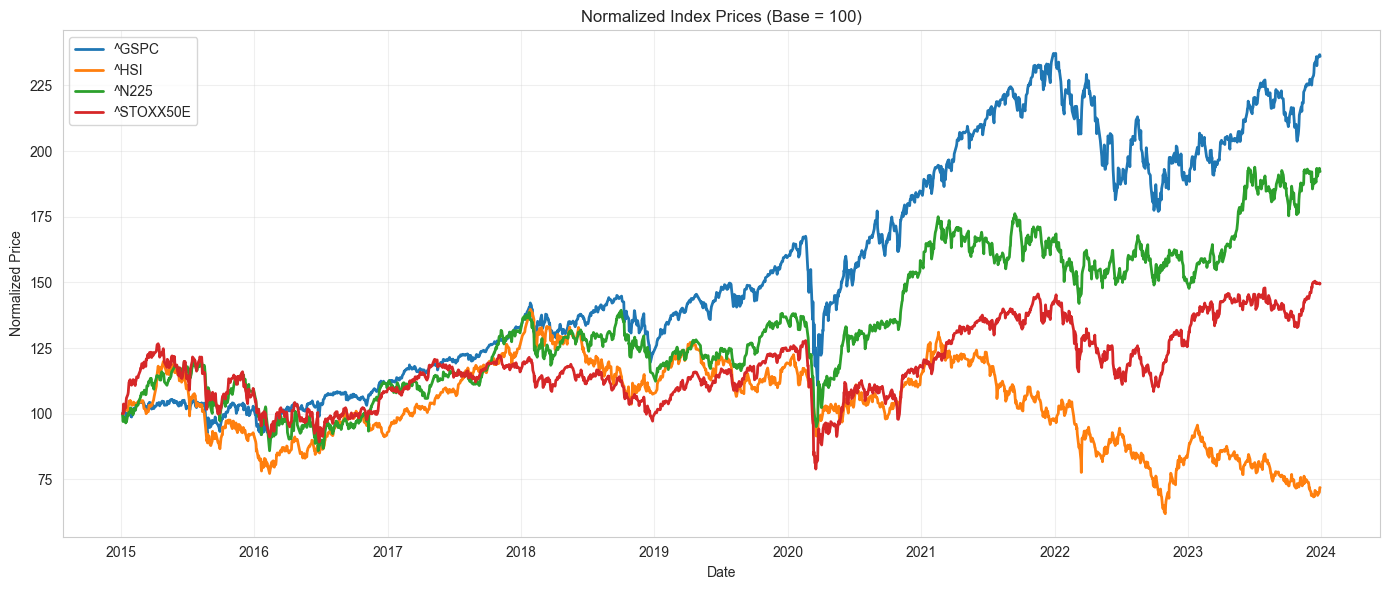

In [8]:
# Normalize prices for comparison
prices_normalized = prices / prices.iloc[0] * 100

plt.figure(figsize=(14, 6))
for col in prices_normalized.columns:
    plt.plot(prices_normalized.index, prices_normalized[col], label=col, linewidth=2)

plt.title('Normalized Index Prices (Base = 100)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/03_price_time_series.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Save Processed Data

In [9]:
# Save data for next steps
returns.to_csv('../data/returns.csv', index=True)
prices.to_csv('../data/prices.csv', index=True)

print("Data saved!")
print(f"Returns shape: {returns.shape}")
print(f"Data ready for VAE training!")

Data saved!
Returns shape: (2001, 4)
Data ready for VAE training!
